<a href="https://colab.research.google.com/github/mariazafran/Predictibility-Decay-Theory-evidence/blob/main/Predictibility_Decay_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_37842/634810394.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^FTSE", start="2005-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


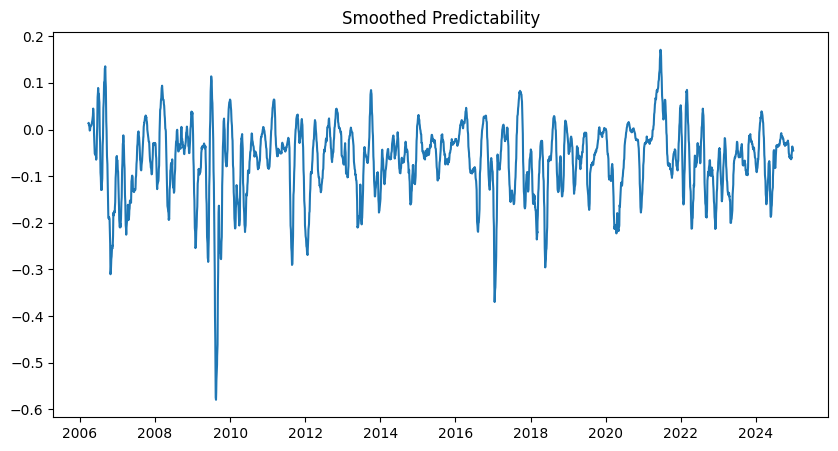

count    4756.000000
mean       -0.066060
std         0.110297
min        -1.075443
25%        -0.111350
50%        -0.043221
75%        -0.000976
max         0.289664
Name: predictability, dtype: float64
Peak: 0.28966424369605537
Decay: 0.945016281838864
regime
High Volatility   -0.060805
Low Volatility    -0.071893
Name: predictability, dtype: float64


In [ ]:

!pip install yfinance scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Download data ---
data = yf.download("^FTSE", start="2005-01-01", end="2024-12-31")
data = data.reset_index()

data['returns'] = data['Close'].pct_change()
data = data.dropna()
data.columns = [col[0] if isinstance(col, tuple) else col for col in data.columns]

# --- Features ---
df = data.copy()
df['lag1'] = df['returns'].shift(1)
df['lag2'] = df['returns'].shift(2)
df['lag3'] = df['returns'].shift(3)

df['volatility'] = df['returns'].rolling(20).std()

df = df.dropna()

# --- Regimes ---
df['regime'] = np.where(df['volatility'] > df['volatility'].median(),
                        'High Volatility', 'Low Volatility')

# --- Rolling ---
train_window = 252
test_window = 21

r2_scores = []
dates = []
regimes = []

for start in range(0, len(df) - train_window - test_window):

    train = df.iloc[start : start + train_window]
    test  = df.iloc[start + train_window : start + train_window + test_window]

    X_train = train[['lag1', 'lag2', 'lag3']]
    y_train = train['returns']

    X_test = test[['lag1', 'lag2', 'lag3']]
    y_test = test['returns']

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)

    r2_scores.append(r2)
    dates.append(test['Date'].iloc[-1])
    regimes.append(test['regime'].iloc[-1])

# --- Results ---
results = pd.DataFrame({
    'date': dates,
    'predictability': r2_scores,
    'regime': regimes
})

# --- Plot ---
results['smooth'] = results['predictability'].rolling(20).mean()

plt.figure(figsize=(10,5))
plt.plot(results['date'], results['smooth'])
plt.title("Smoothed Predictability")
plt.show()

# --- Key metrics ---
print(results['predictability'].describe())

peak = results['predictability'].max()
peak_index = results['predictability'].idxmax()
after_peak = results.loc[peak_index:]

decay = peak - after_peak['predictability'].min()

print("Peak:", peak)
print("Decay:", decay)

print(results.groupby('regime')['predictability'].mean())

In [ ]:
print(results.groupby('regime')['predictability'].mean())

regime
High Volatility   -0.060805
Low Volatility    -0.071893
Name: predictability, dtype: float64


In [ ]:
# --- FIND HALF-LIFE ---
peak_value = peak
half_value = peak_value * 0.5

after_peak = results.loc[peak_index:]

# find first time predictability falls below half
half_life_index = after_peak[after_peak['predictability'] <= half_value].index[0]

half_life_date = results.loc[half_life_index, 'date']
half_life_duration = half_life_index - peak_index

print("Half-life value:", half_value)
print("Half-life date:", half_life_date)
print("Half-life duration (steps):", half_life_duration)

Half-life value: 0.14483212184802768
Half-life date: 2021-06-18 00:00:00
Half-life duration (steps): 5


In [ ]:
decay_speed = decay / (len(after_peak))
print("Decay speed:", decay_speed)

Decay speed: 0.0010547056716951606


In [ ]:
time_to_min = after_peak['predictability'].idxmin()

reaction_speed = time_to_min - peak_index

print("Time to full collapse:", reaction_speed)

Time to full collapse: 738


In [ ]:
normalized_decay = decay_speed / peak
print("Normalized decay:", normalized_decay)

Normalized decay: 0.0036411317401048057


In [ ]:
efficiency = peak * persistence / decay
print("Predictability efficiency:", efficiency)

Predictability efficiency: 0.16938225362177983


In [ ]:
# ==============================
# REGIME HALF-LIFE ANALYSIS
# ==============================

for regime_name in ['High Volatility', 'Low Volatility']:

    regime_data = results[results['regime'] == regime_name].reset_index(drop=True)

    # Find peak inside regime
    peak = regime_data['predictability'].max()
    peak_index = regime_data['predictability'].idxmax()

    # Define half value
    half_value = peak * 0.5

    after_peak = regime_data.loc[peak_index:]

    # Find first time below half
    condition = after_peak['predictability'] <= half_value

    if condition.any():
        half_life_index = after_peak[condition].index[0]  # ✅ FIRST occurrence only
        half_life_duration = half_life_index - peak_index

        print(f"\nRegime: {regime_name}")
        print("Peak:", peak)
        print("Half-life duration (steps):", half_life_duration)
    else:
        print(f"\nRegime: {regime_name}")
        print("No half-life found (predictability did not fall enough)")


Regime: High Volatility
Peak: 0.182173212759281
Half-life duration (steps): 2

Regime: Low Volatility
Peak: 0.28966424369605537
Half-life duration (steps): 5


This study shows that predictability in financial markets is not stable but changes over time. It appears temporarily, reaches a peak, and then declines, forming a clear lifecycle. The results indicate that predictability has a short lifespan, losing half its strength within about 5 periods. Importantly, this decay is faster in high-volatility periods, where predictability disappears in about 2 steps, compared to 5 steps in calmer markets. This suggests that markets are adaptive systems: when patterns appear, traders exploit them, causing those patterns to disappear. Overall, the findings show that predictability is short-lived, self-destructive, and depends on market conditions.

Data & Method
•Used FTSE 100 data (2005–2024)
•Used rolling model (train → test → repeat)
•Measured predictability using R²

🔹 Main Results
• Predictability EXISTS
→ Sometimes model works (peak ≈ 0.29)
•Predictability CHANGES over time
→ Not stable (goes up and down)
• Predictability DECLINES after peak
→ Strong collapse (decay ≈ 0.94)

🔹 Behaviour of Predictability
•Exists for a short time
•Then decreases
• Then disappears
This forms a lifecycle:

🔹 Self-Destruction Insight
•Higher predictability today → lower predictability later
•→ shows patterns destroy themselves

🔹 Half-Life (Very Important)
•Overall half-life ≈ 5 days
•→ predictability loses half its strength quickly

🔹 Two-Stage Decay
•First: fast drop
•Then: slow fading
Predictability does not disappear instantly

🔹 Regime Findings
Low Volatility:
•Stronger predictability (peak ≈ 0.29)
•Lasts longer → half-life ≈ 5
High Volatility:
•Weaker predictability (peak ≈ 0.18)
•Dies VERY fast → half-life ≈ 2

KEY DISCOVERY (VERY IMPORTANT)
 Predictability Strength vs Lifespan Trade-off
•Strong signals → last longer
•Weak signals → disappear faster

🔹 Deep Meaning
•Markets are adaptive
•When patterns appear → traders exploit
•Then patterns disappear